<a href="https://colab.research.google.com/github/leonmarienga/Android-app/blob/main/treemodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Loading and inspecting the dataset**


---


In this step, I loaded the OpenFEMA master dataset into pandas and checked its structure.

The dataset contains 971 rows and 45 columns. The output also shows that the data includes a mix of:

* numeric columns
* categorical/text columns
* boolean columns
* datetime columns

This is important because different column types need different preprocessing before modeling.

The inspection also shows that some columns have missing values, especially a few obligation-related date columns. That means missing-data handling will be needed later.

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_excel('/content/master_openfema_40plus.xlsx')

In [ ]:
df.head()

,disasterNumber,state,declarationType,declarationRequestNumber,fyDeclared,declarationDate,incidentType,incidentBeginDate,incidentEndDate,designatedArea,...,maxDateObligated,daysToFirstObligationFromDeclaration,obligationSpanDays,responseComplexityScore,missionDensity,agencyDensity,fundingPerMission,fundingPerAgency,fundingPerDay,eventScale
0,1865,AK,DR,9128,2010,2009-12-18T00:00:00.000Z,Severe Storm,2009-10-06T00:00:00.000Z,2009-10-11T00:00:00.000Z,Kodiak Island (Borough),...,NaT,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,Local
1,1866,AL,DR,9123,2010,2009-12-22T00:00:00.000Z,Hurricane,2009-11-09T00:00:00.000Z,2009-11-10T00:00:00.000Z,Mobile (County),...,NaT,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,Local
2,1870,AL,DR,9129,2010,2009-12-31T00:00:00.000Z,Severe Storm,2009-12-12T00:00:00.000Z,2009-12-18T00:00:00.000Z,Russell (County),...,NaT,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,Local
3,1908,AL,DR,10051,2010,2010-05-03T00:00:00.000Z,Severe Storm,2010-04-24T00:00:00.000Z,2010-04-25T00:00:00.000Z,Walker (County),...,NaT,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,Local
4,1861,AR,DR,9121,2010,2009-12-03T00:00:00.000Z,Severe Storm,2009-10-29T00:00:00.000Z,2009-11-08T00:00:00.000Z,Woodruff (County),...,NaT,NaN,NaN,0,0.0,0.0,0.0,0.0,0.0,Local


In [ ]:
df.shape

(971, 45)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 45 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   disasterNumber                        971 non-null    int64         
 1   state                                 971 non-null    object        
 2   declarationType                       971 non-null    object        
 3   declarationRequestNumber              971 non-null    int64         
 4   fyDeclared                            971 non-null    int64         
 5   declarationDate                       971 non-null    object        
 6   incidentType                          971 non-null    object        
 7   incidentBeginDate                     971 non-null    object        
 8   incidentEndDate                       971 non-null    object        
 9   designatedArea                        971 non-null    object        
 10  pl

**2. Checking missing values**


---



In this step, I checked which columns have missing values and how many are missing.

The results show that most columns are complete, but a few obligation-related columns have many missing values, especially:

* lastIAFilingDate
* minDateObligated
* maxDateObligated
* daysToFirstObligationFromDeclaration
* obligationSpanDays

To understand whether this missingness was random or meaningful, I created a flag called minDateObligated_missing.

The follow-up checks showed that when minDateObligated is missing:

* missionAssignmentCount is 0
* uniqueAgencyCount is 0
* uniqueMaTypeCount is 0
* uniquePriorityCount is 0
* totalObligatedFunding is 0

***This means the missing values are structural, not random.*** In other words, these fields are missing because no obligation activity occurred for those disasters, not because the data was lost.

This is important because it tells us that the missingness itself carries information and must be handled carefully during preprocessing.

In [ ]:
print(df.isna().sum().sort_values(ascending=False))

lastIAFilingDate                        629
maxDateObligated                        538
daysToFirstObligationFromDeclaration    538
minDateObligated                        538
obligationSpanDays                      538
declarationDate                           0
incidentType                              0
incidentBeginDate                         0
disasterNumber                            0
state                                     0
declarationType                           0
declarationRequestNumber                  0
fyDeclared                                0
iaProgramDeclared                         0
ihProgramDeclared                         0
placeCode                                 0
designatedArea                            0
incidentEndDate                           0
paProgramDeclared                         0
hmProgramDeclared                         0
declarationDate_dt                        0
stateFullName                             0
expectedResourceLevel           

In [ ]:
df["minDateObligated_missing"] = df["minDateObligated"].isna()
print(df["minDateObligated_missing"].value_counts())

minDateObligated_missing
True     538
False    433
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df["minDateObligated_missing"], df["missionAssignmentCount"]))

missionAssignmentCount    0     1     2     3     4     5     6     7     \
minDateObligated_missing                                                   
False                        0     2    40    32    22    24    21    22   
True                       538     0     0     0     0     0     0     0   

missionAssignmentCount    8     9     ...  537   539   576   719   721   740   \
minDateObligated_missing              ...                                       
False                       16    17  ...     1     1     1     1     1     1   
True                         0     0  ...     0     0     0     0     0     0   

missionAssignmentCount    787   813   1083  1725  
minDateObligated_missing                          
False                        1     1     1     1  
True                         0     0     0     0  

[2 rows x 134 columns]


In [ ]:
print(df.groupby("minDateObligated_missing")[[
    "missionAssignmentCount",
    "uniqueAgencyCount",
    "uniqueMaTypeCount",
    "uniquePriorityCount",
    "totalObligatedFunding"
]].mean())

                          missionAssignmentCount  uniqueAgencyCount  \
minDateObligated_missing                                              
False                                  64.307159           7.337182   
True                                    0.000000           0.000000   

                          uniqueMaTypeCount  uniquePriorityCount  \
minDateObligated_missing                                           
False                              1.337182             2.053118   
True                               0.000000             0.000000   

                          totalObligatedFunding  
minDateObligated_missing                         
False                              4.703934e+07  
True                               0.000000e+00  


**3. Removing leakage columns**


---



In this step, I identified and removed columns that would cause data leakage.

These were columns that were either:

* directly based on the target (totalObligatedFunding)
* derived from obligation amounts
* or based on post-event obligation timing

Examples include:

* totalObligatedFunding
* avgObligationPerMission
* fundingPerMission
* fundingPerAgency
* fundingPerDay
* obligation date-related columns

***These columns cannot be used as predictors because they already contain information about the outcome we are trying to predict.***

After dropping them, the predictor dataset X was reduced to 34 columns. This left only the candidate input features for the model and removed variables that would unfairly inflate performance.

In [ ]:
suspicious_cols = [
    "totalObligatedFunding",
    "avgObligationPerMission",
    "medianObligationPerMission",
    "maxObligationPerMission",
    "minDateObligated",
    "maxDateObligated",
    "daysToFirstObligationFromDeclaration",
    "obligationSpanDays",
    "fundingPerMission",
    "fundingPerAgency",
    "fundingPerDay"
]

print(suspicious_cols)

['totalObligatedFunding', 'avgObligationPerMission', 'medianObligationPerMission', 'maxObligationPerMission', 'minDateObligated', 'maxDateObligated', 'daysToFirstObligationFromDeclaration', 'obligationSpanDays', 'fundingPerMission', 'fundingPerAgency', 'fundingPerDay']


In [ ]:
leakage_cols = [
    "totalObligatedFunding",
    "avgObligationPerMission",
    "medianObligationPerMission",
    "maxObligationPerMission",
    "minDateObligated",
    "maxDateObligated",
    "daysToFirstObligationFromDeclaration",
    "obligationSpanDays",
    "fundingPerMission",
    "fundingPerAgency",
    "fundingPerDay",
    "eventScale"
]

X = df.drop(columns=leakage_cols)
print(X.shape)
print(X.columns.tolist())

(971, 34)
['disasterNumber', 'state', 'declarationType', 'declarationRequestNumber', 'fyDeclared', 'declarationDate', 'incidentType', 'incidentBeginDate', 'incidentEndDate', 'designatedArea', 'placeCode', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'lastIAFilingDate', 'declarationDate_dt', 'incidentBeginDate_dt', 'incidentEndDate_dt', 'durationDays', 'declarationDelayDays', 'stateFullName', 'expectedResourceLevel', 'expectedResourceScore', 'disasterCategory', 'durationClass', 'missionAssignmentCount', 'uniqueAgencyCount', 'uniqueMaTypeCount', 'uniquePriorityCount', 'responseComplexityScore', 'missionDensity', 'agencyDensity', 'minDateObligated_missing']


In [ ]:
id_cols = [
    "disasterNumber",
    "declarationRequestNumber",
    "placeCode"
]

raw_date_cols = [
    "declarationDate",
    "incidentBeginDate",
    "incidentEndDate",
    "lastIAFilingDate"
]

datetime_cols = [
    "declarationDate_dt",
    "incidentBeginDate_dt",
    "incidentEndDate_dt"
]

bool_cols = [
    "ihProgramDeclared",
    "iaProgramDeclared",
    "paProgramDeclared",
    "hmProgramDeclared"
]

categorical_cols = [
    "state",
    "declarationType",
    "incidentType",
    "designatedArea",
    "stateFullName",
    "expectedResourceLevel",
    "disasterCategory",
    "durationClass"
]

numeric_cols = [
    "fyDeclared",
    "durationDays",
    "declarationDelayDays",
    "expectedResourceScore",
    "missionAssignmentCount",
    "uniqueAgencyCount",
    "uniqueMaTypeCount",
    "uniquePriorityCount",
    "responseComplexityScore",
    "missionDensity",
    "agencyDensity"
]

inspection_flag_cols = [
    "minDateObligated_missing"
]

print("ID cols:", id_cols)
print("Raw date cols:", raw_date_cols)
print("Datetime cols:", datetime_cols)
print("Bool cols:", bool_cols)
print("Categorical cols:", categorical_cols)
print("Numeric cols:", numeric_cols)
print("Inspection flag cols:", inspection_flag_cols)

ID cols: ['disasterNumber', 'declarationRequestNumber', 'placeCode']
Raw date cols: ['declarationDate', 'incidentBeginDate', 'incidentEndDate', 'lastIAFilingDate']
Datetime cols: ['declarationDate_dt', 'incidentBeginDate_dt', 'incidentEndDate_dt']
Bool cols: ['ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']
Categorical cols: ['state', 'declarationType', 'incidentType', 'designatedArea', 'stateFullName', 'expectedResourceLevel', 'disasterCategory', 'durationClass']
Numeric cols: ['fyDeclared', 'durationDays', 'declarationDelayDays', 'expectedResourceScore', 'missionAssignmentCount', 'uniqueAgencyCount', 'uniqueMaTypeCount', 'uniquePriorityCount', 'responseComplexityScore', 'missionDensity', 'agencyDensity']
Inspection flag cols: ['minDateObligated_missing']


**4. Cleaning the remaining predictors and grouping feature types**


---


In this step, I removed columns that were not suitable for modeling, such as:

* identifier columns
* raw date columns
* datetime columns
* duplicated information such as stateFullName
* the missingness flag used only for investigation

After removing these, the dataset was reduced to 22 predictor columns.

I then grouped the remaining columns into three types:

categorical features: text-based variables that will need encoding
boolean features: yes/no variables
numeric features: count and continuous variables

In [ ]:
drop_cols_step7 = [
    "disasterNumber",
    "declarationRequestNumber",
    "placeCode",
    "declarationDate",
    "incidentBeginDate",
    "incidentEndDate",
    "lastIAFilingDate",
    "declarationDate_dt",
    "incidentBeginDate_dt",
    "incidentEndDate_dt",
    "minDateObligated_missing",
    "stateFullName"
]

X = X.drop(columns=drop_cols_step7)

print(X.shape)
print(X.columns.tolist())

(971, 22)
['state', 'declarationType', 'fyDeclared', 'incidentType', 'designatedArea', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'durationDays', 'declarationDelayDays', 'expectedResourceLevel', 'expectedResourceScore', 'disasterCategory', 'durationClass', 'missionAssignmentCount', 'uniqueAgencyCount', 'uniqueMaTypeCount', 'uniquePriorityCount', 'responseComplexityScore', 'missionDensity', 'agencyDensity']


In [ ]:
categorical_cols = [
    "state",
    "declarationType",
    "incidentType",
    "designatedArea",
    "expectedResourceLevel",
    "disasterCategory",
    "durationClass"
]

bool_cols = [
    "ihProgramDeclared",
    "iaProgramDeclared",
    "paProgramDeclared",
    "hmProgramDeclared"
]

numeric_cols = [
    "fyDeclared",
    "durationDays",
    "declarationDelayDays",
    "expectedResourceScore",
    "missionAssignmentCount",
    "uniqueAgencyCount",
    "uniqueMaTypeCount",
    "uniquePriorityCount",
    "responseComplexityScore",
    "missionDensity",
    "agencyDensity"
]

print("Categorical:", len(categorical_cols), categorical_cols)
print("Boolean:", len(bool_cols), bool_cols)
print("Numeric:", len(numeric_cols), numeric_cols)
print("Total:", len(categorical_cols) + len(bool_cols) + len(numeric_cols))

Categorical: 7 ['state', 'declarationType', 'incidentType', 'designatedArea', 'expectedResourceLevel', 'disasterCategory', 'durationClass']
Boolean: 4 ['ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']
Numeric: 11 ['fyDeclared', 'durationDays', 'declarationDelayDays', 'expectedResourceScore', 'missionAssignmentCount', 'uniqueAgencyCount', 'uniqueMaTypeCount', 'uniquePriorityCount', 'responseComplexityScore', 'missionDensity', 'agencyDensity']
Total: 22


**5. Inspecting and cleaning the target variable**

---



In this step, I examined the target variable, totalObligatedFunding, before modeling.

The summary showed that the target is highly skewed, with:

* many zero values
* one negative value
* and a very large maximum value

This means the raw target is not well suited for direct modeling.

I then checked the negative value and found that there was only one negative case in the dataset. Since negative obligated funding is not meaningful for the modeling goal, I clipped negative values to zero and created a cleaned version called target_funding_clean.

After this step:

there were no negative values left
the number of zero-funded cases became 565

This cleaning step was important because it made the target consistent and ready for later transformation and modeling.

In [ ]:
print(df["totalObligatedFunding"].describe())
print("Missing:", df["totalObligatedFunding"].isna().sum())
print("Zeros:", (df["totalObligatedFunding"] == 0).sum())
print("Skew:", df["totalObligatedFunding"].skew())

count    9.710000e+02
mean     2.097635e+07
std      1.904758e+08
min     -4.040310e+04
25%      0.000000e+00
50%      0.000000e+00
75%      1.590370e+05
max      4.379126e+09
Name: totalObligatedFunding, dtype: float64
Missing: 0
Zeros: 564
Skew: 17.621314713791865


In [ ]:
neg_mask = df["totalObligatedFunding"] < 0

print("Negative count:", neg_mask.sum())
print("\nNegative rows preview:")
print(df.loc[neg_mask, [
    "disasterNumber" if "disasterNumber" in df.columns else df.columns[0],
    "state",
    "incidentType",
    "missionAssignmentCount",
    "uniqueAgencyCount",
    "totalObligatedFunding"
]].head(20))

Negative count: 1

Negative rows preview:
     disasterNumber state incidentType  missionAssignmentCount  \
486            4357    AS    Hurricane                      19   

     uniqueAgencyCount  totalObligatedFunding  
486                  6               -40403.1  


In [ ]:
df["target_funding_clean"] = df["totalObligatedFunding"].clip(lower=0)

## **6. Transforming the target and reviewing the predictors**

---



In this step, I applied a log transformation to the cleaned funding target using log1p. This created a new target variable called log_target_funding.

The reason for this was to reduce the strong skew in the original funding values. After the transformation, the skew dropped greatly, which means the target became much more suitable for modeling.

I then assigned this transformed column to y, which is the final target used by the models.

After that, I reviewed the predictor dataset X using summary statistics. This helped show:

* which variables are categorical
* which are numeric
* which variables have very little variation
* and which operational variables are highly concentrated around zero

In [ ]:
print(df["target_funding_clean"].describe())
print("Negative values after clipping:", (df["target_funding_clean"] < 0).sum())
print("Zeros after clipping:", (df["target_funding_clean"] == 0).sum())

count    9.710000e+02
mean     2.097639e+07
std      1.904758e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.590370e+05
max      4.379126e+09
Name: target_funding_clean, dtype: float64
Negative values after clipping: 0
Zeros after clipping: 565


In [ ]:
import numpy as np

df["log_target_funding"] = np.log1p(df["target_funding_clean"])
y = df["log_target_funding"]

In [ ]:
print(df["log_target_funding"].describe())
print("Skew:", df["log_target_funding"].skew())

count    971.000000
mean       5.430525
std        6.834699
min        0.000000
25%        0.000000
50%        0.000000
75%       11.976837
max       22.200115
Name: log_target_funding, dtype: float64
Skew: 0.6731212800960986


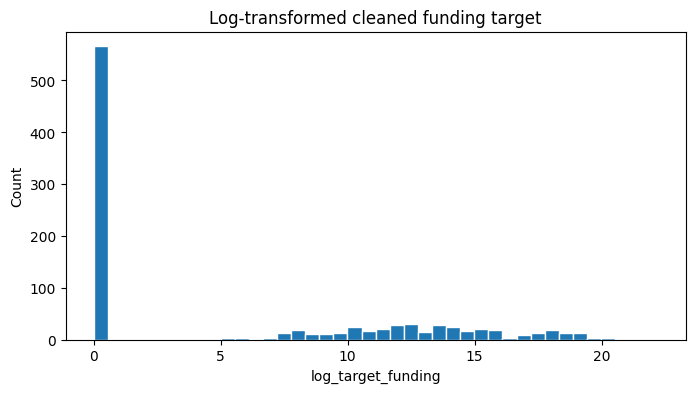

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["log_target_funding"], bins=40, edgecolor="white")
plt.title("Log-transformed cleaned funding target")
plt.xlabel("log_target_funding")
plt.ylabel("Count")
plt.show()

In [ ]:
print(X.describe(include="all").T)

                         count unique                  top freq         mean  \
state                      971     56                   CA   41          NaN   
declarationType            971      1                   DR  971          NaN   
fyDeclared               971.0    NaN                  NaN  NaN  2017.110196   
incidentType               971     20         Severe Storm  430          NaN   
designatedArea             971    391  Washington (County)   37          NaN   
ihProgramDeclared          971      2                False  624          NaN   
iaProgramDeclared          971      1                False  971          NaN   
paProgramDeclared          971      2                 True  940          NaN   
hmProgramDeclared          971      2                 True  970          NaN   
durationDays             971.0    NaN                  NaN  NaN    85.668383   
declarationDelayDays     971.0    NaN                  NaN  NaN     53.61174   
expectedResourceLevel      971      4   

**7. Finalizing the predictor set**

---


In this step, I removed a few additional columns that were not useful for modeling:

* declarationType, because it had no variation
* iaProgramDeclared, because it also had no variation
* designatedArea, because it had too many unique categories and would
* create too many encoded columns

After removing these, the final predictor dataset contained 19 features.

I then grouped these features into:

* 5 categorical variables
* 3 boolean variables
* 11 numeric variables

In [ ]:
drop_now = ["declarationType", "iaProgramDeclared", "designatedArea"]

X = X.drop(columns=drop_now)

print(X.shape)
print(X.columns.tolist())

(971, 19)
['state', 'fyDeclared', 'incidentType', 'ihProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'durationDays', 'declarationDelayDays', 'expectedResourceLevel', 'expectedResourceScore', 'disasterCategory', 'durationClass', 'missionAssignmentCount', 'uniqueAgencyCount', 'uniqueMaTypeCount', 'uniquePriorityCount', 'responseComplexityScore', 'missionDensity', 'agencyDensity']


In [ ]:
categorical_cols = [
    "state",
    "incidentType",
    "expectedResourceLevel",
    "disasterCategory",
    "durationClass"
]

bool_cols = [
    "ihProgramDeclared",
    "paProgramDeclared",
    "hmProgramDeclared"
]

numeric_cols = [
    "fyDeclared",
    "durationDays",
    "declarationDelayDays",
    "expectedResourceScore",
    "missionAssignmentCount",
    "uniqueAgencyCount",
    "uniqueMaTypeCount",
    "uniquePriorityCount",
    "responseComplexityScore",
    "missionDensity",
    "agencyDensity"
]

print("Categorical:", len(categorical_cols), categorical_cols)
print("Boolean:", len(bool_cols), bool_cols)
print("Numeric:", len(numeric_cols), numeric_cols)
print("Total:", len(categorical_cols) + len(bool_cols) + len(numeric_cols))

Categorical: 5 ['state', 'incidentType', 'expectedResourceLevel', 'disasterCategory', 'durationClass']
Boolean: 3 ['ihProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared']
Numeric: 11 ['fyDeclared', 'durationDays', 'declarationDelayDays', 'expectedResourceScore', 'missionAssignmentCount', 'uniqueAgencyCount', 'uniqueMaTypeCount', 'uniquePriorityCount', 'responseComplexityScore', 'missionDensity', 'agencyDensity']
Total: 19


**8. Splitting the data and building the Random Forest model**


---


In this step, I split the dataset into training and testing sets.

* The training set contains 776 rows
* The testing set contains 195 rows

This is important because the model must learn from one part of the data and then be evaluated on a separate part it has not seen before.

Next, I built the Random Forest pipeline. The pipeline handles preprocessing and modeling in one workflow:

* categorical variables are filled with the most common value if needed * and then one-hot encoded
* numeric and boolean variables are passed through directly
* the model used is a Random Forest Regressor with 200 trees

After that, I fitted the model on the training data.

Finally, I generated predictions for the test set. These predictions are still on the log-transformed funding scale, because the model was trained to predict log_target_funding.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (776, 19)
X_test: (195, 19)
y_train: (776,)
y_test: (195,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_bool_features = numeric_cols + bool_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_cols),
        ("num_bool", "passthrough", numeric_bool_features)
    ]
)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipeline created successfully.")

Pipeline created successfully.


In [ ]:
rf_pipeline.fit(X_train, y_train)
print("Model fitted successfully.")

Model fitted successfully.


In [ ]:
y_pred_log = rf_pipeline.predict(X_test)
print(y_pred_log[:10])

[ 0.         19.3558105   0.          0.          0.         17.92046592
 18.51239371  8.82992957 12.66937274 11.93013306]


**9. Evaluating the Random Forest model**

---



In this step, I evaluated the Random Forest model on both the log-transformed target and the original dollar scale.

On the log scale, the model performed very well:

* RMSE = 1.84
* MAE = 0.75
* R² = 0.928

This means the model explained about 92.8% of the variation in the log-transformed funding target, which shows strong predictive performance after handling skewness.

I then converted the predictions back to real dollar values to see how the model performs in practical terms. On the original scale, performance dropped:

* RMSE ≈ 85.2 million
* MAE ≈ 11.4 million
* R² = 0.327

This shows that while the model captures the overall structure of the data well, it is less precise when predicting exact dollar amounts, especially for the largest disasters.

To understand this better, I compared actual and predicted values and sorted the biggest errors. ***This showed that the largest mistakes came from a small number of extremely expensive disasters.*** In other words, the model performs well overall, but the extreme high-cost cases remain difficult to predict accurately.

Finally, I checked feature importance. The results showed that the model relied mainly on operational response variables, especially:

responseComplexityScore
missionAssignmentCount

This suggests that funding is driven much more by the scale and complexity of the response effort than by basic disaster descriptors alone.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

print("Log-scale performance:")
print("RMSE:", rmse_log)
print("MAE :", mae_log)
print("R²  :", r2_log)

Log-scale performance:
RMSE: 1.8399536017247662
MAE : 0.7524168236036082
R²  : 0.9276143338548279


In [ ]:
y_test_raw = np.expm1(y_test)
y_pred_raw = np.expm1(y_pred_log)

rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
r2_raw = r2_score(y_test_raw, y_pred_raw)

print("Original-dollar performance:")
print("RMSE:", rmse_raw)
print("MAE :", mae_raw)
print("R²  :", r2_raw)

Original-dollar performance:
RMSE: 85229853.71882945
MAE : 11409812.67703753
R²  : 0.32662360651486955


In [ ]:
comparison = pd.DataFrame({
    "actual_log": y_test,
    "pred_log": y_pred_log,
    "actual_raw": y_test_raw,
    "pred_raw": y_pred_raw
})

comparison["abs_error_raw"] = abs(comparison["actual_raw"] - comparison["pred_raw"])
comparison["abs_error_log"] = abs(comparison["actual_log"] - comparison["pred_log"])

print(comparison.sort_values("abs_error_raw", ascending=False).head(20))

     actual_log   pred_log    actual_raw      pred_raw  abs_error_raw  \
836   21.048257  19.355810  1.384019e+09  2.547544e+08   1.129264e+09   
428   19.391889  19.988886  2.641134e+08  4.798030e+08   2.156896e+08   
633   19.363388  18.313159  2.566921e+08  8.980570e+07   1.668864e+08   
552   18.891186  13.992501  1.600802e+08  1.193619e+06   1.588866e+08   
687   19.011143  17.730322  1.804822e+08  5.013964e+07   1.303426e+08   
896   15.736363  18.512394  6.826774e+06  1.096050e+08   1.027782e+08   
669   18.615935  16.914140  1.215620e+08  2.216756e+07   9.939441e+07   
604   16.430539  17.670249  1.366760e+07  4.721627e+07   3.354867e+07   
657   18.310853  17.920466  8.959883e+07  6.064004e+07   2.895880e+07   
695   17.061213  17.767004  2.567973e+07  5.201301e+07   2.633328e+07   
629   17.302919  17.782305  3.270110e+07  5.281498e+07   2.011388e+07   
798   18.174855  17.915522  7.820583e+07  6.034099e+07   1.786484e+07   
605   17.331754  17.757276  3.365774e+07  5.150947e

In [ ]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

                              feature  importance
93  num_bool__responseComplexityScore    0.557015
89   num_bool__missionAssignmentCount    0.335633
90        num_bool__uniqueAgencyCount    0.021149
94           num_bool__missionDensity    0.018484
95            num_bool__agencyDensity    0.015668
87     num_bool__declarationDelayDays    0.005292
92      num_bool__uniquePriorityCount    0.005079
85               num_bool__fyDeclared    0.004062
86             num_bool__durationDays    0.003565
54                      cat__state_WV    0.003551
67        cat__incidentType_Snowstorm    0.002994
35                      cat__state_NM    0.002591
91        num_bool__uniqueMaTypeCount    0.002353
88    num_bool__expectedResourceScore    0.001801
19                      cat__state_KY    0.001734
76  cat__expectedResourceLevel_Medium    0.001174
20                      cat__state_LA    0.000950
57    cat__incidentType_Coastal Storm    0.000909
4                       cat__state_AZ    0.000876


**10. Ablation test: removing responseComplexityScore**

---



In this step, I tested how important responseComplexityScore really was by removing it from the predictor set and training the Random Forest model again.

The goal was to check whether the model truly depended on this one variable, or whether the same information was already contained in other related mission-response features.

After removing responseComplexityScore, the model performance changed only slightly:

* RMSE = 1.846
* MAE = 0.755
* R² = 0.927

This is almost the same as the full model.

This shows that although responseComplexityScore appeared as the most important feature, the model was not strongly dependent on it alone. Its predictive signal was largely replaced by other related variables such as mission count and agency count.

This result suggests that the real predictive strength comes from the mission-response feature group as a whole, rather than from a single composite feature.

In [ ]:
X_ablate = X.drop(columns=["responseComplexityScore"])

categorical_cols_ablate = [
    "state",
    "incidentType",
    "expectedResourceLevel",
    "disasterCategory",
    "durationClass"
]

bool_cols_ablate = [
    "ihProgramDeclared",
    "paProgramDeclared",
    "hmProgramDeclared"
]

numeric_cols_ablate = [
    "fyDeclared",
    "durationDays",
    "declarationDelayDays",
    "expectedResourceScore",
    "missionAssignmentCount",
    "uniqueAgencyCount",
    "uniqueMaTypeCount",
    "uniquePriorityCount",
    "missionDensity",
    "agencyDensity"
]

from sklearn.model_selection import train_test_split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_ablate, y, test_size=0.2, random_state=42
)

print(X_train_a.shape, X_test_a.shape)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_transformer_a = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_bool_features_a = numeric_cols_ablate + bool_cols_ablate

preprocessor_a = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer_a, categorical_cols_ablate),
        ("num_bool", "passthrough", numeric_bool_features_a)
    ]
)

rf_pipeline_a = Pipeline(steps=[
    ("preprocessor", preprocessor_a),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_pipeline_a.fit(X_train_a, y_train_a)
y_pred_log_a = rf_pipeline_a.predict(X_test_a)

rmse_log_a = np.sqrt(mean_squared_error(y_test_a, y_pred_log_a))
mae_log_a = mean_absolute_error(y_test_a, y_pred_log_a)
r2_log_a = r2_score(y_test_a, y_pred_log_a)

print("Ablation without responseComplexityScore")
print("Log-scale performance:")
print("RMSE:", rmse_log_a)
print("MAE :", mae_log_a)
print("R²  :", r2_log_a)

(776, 18) (195, 18)
Ablation without responseComplexityScore
Log-scale performance:
RMSE: 1.8455118841336273
MAE : 0.7546373283307561
R²  : 0.9271763361953533


**11. Descriptor-only Random Forest model**

---



In this step, I trained a second Random Forest model using only the basic disaster descriptor variables and excluding all mission-response variables.

The purpose of this test was to see how well the model could perform using only general disaster information such as:

* state
* year
* incident type
* program declaration flags
* duration and delay measures
* expected resource indicators

This reduced the predictor set to 12 variables.

After training and testing this descriptor-only model, performance dropped substantially:

* RMSE = 4.555
* MAE = 3.198
* R² = 0.556

Compared with the full model, this is a major decline.

This shows that the basic disaster descriptors alone explain only part of the funding pattern. The much better performance of the full model confirms that the strongest predictive signal comes from the mission-response operational variables, not just the broad disaster characteristics.

In [ ]:
descriptor_cols = [
    "state",
    "fyDeclared",
    "incidentType",
    "ihProgramDeclared",
    "paProgramDeclared",
    "hmProgramDeclared",
    "durationDays",
    "declarationDelayDays",
    "expectedResourceLevel",
    "expectedResourceScore",
    "disasterCategory",
    "durationClass"
]

X_desc = X[descriptor_cols].copy()
print(X_desc.shape)
print(X_desc.columns.tolist())

categorical_cols_desc = [
    "state",
    "incidentType",
    "expectedResourceLevel",
    "disasterCategory",
    "durationClass"
]

bool_cols_desc = [
    "ihProgramDeclared",
    "paProgramDeclared",
    "hmProgramDeclared"
]

numeric_cols_desc = [
    "fyDeclared",
    "durationDays",
    "declarationDelayDays",
    "expectedResourceScore"
]

print("Categorical:", len(categorical_cols_desc))
print("Boolean:", len(bool_cols_desc))
print("Numeric:", len(numeric_cols_desc))
print("Total:", len(categorical_cols_desc) + len(bool_cols_desc) + len(numeric_cols_desc))

from sklearn.model_selection import train_test_split

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_desc, y, test_size=0.2, random_state=42
)

print(X_train_d.shape, X_test_d.shape)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_transformer_d = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_bool_features_d = numeric_cols_desc + bool_cols_desc

preprocessor_d = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer_d, categorical_cols_desc),
        ("num_bool", "passthrough", numeric_bool_features_d)
    ]
)

rf_pipeline_d = Pipeline(steps=[
    ("preprocessor", preprocessor_d),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_pipeline_d.fit(X_train_d, y_train_d)
y_pred_log_d = rf_pipeline_d.predict(X_test_d)

rmse_log_d = np.sqrt(mean_squared_error(y_test_d, y_pred_log_d))
mae_log_d = mean_absolute_error(y_test_d, y_pred_log_d)
r2_log_d = r2_score(y_test_d, y_pred_log_d)

print("Descriptor-only Random Forest")
print("Log-scale performance:")
print("RMSE:", rmse_log_d)
print("MAE :", mae_log_d)
print("R²  :", r2_log_d)

(971, 12)
['state', 'fyDeclared', 'incidentType', 'ihProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'durationDays', 'declarationDelayDays', 'expectedResourceLevel', 'expectedResourceScore', 'disasterCategory', 'durationClass']
Categorical: 5
Boolean: 3
Numeric: 4
Total: 12
(776, 12) (195, 12)
Descriptor-only Random Forest
Log-scale performance:
RMSE: 4.5547011614616695
MAE : 3.1981324651939045
R²  : 0.5564336338489555


**12. Comparing Random Forest training and testing results**

---



In this step, I compared the Random Forest model’s performance on the training set and the test set, using both the log-transformed target and the original dollar scale.

Log-scale results
* Train R² = 0.991
* Test R² = 0.928
* Train RMSE = 0.634
* Test RMSE = 1.840
* Train MAE = 0.288
* Test MAE = 0.752

These results show that the model fits the training data extremely well and still performs strongly on unseen test data. The training results are better than the test results, which suggests some overfitting, but the test performance remains strong.

* Original dollar scale results
* Train R² = 0.612
* Test R² = 0.327
* Train RMSE ≈ 128.6 million
* Test RMSE ≈ 85.2 million
* Train MAE ≈ 10.9 million
* Test MAE ≈ 11.4 million

On the original dollar scale, the model performs worse than on the log scale. This is expected because the original funding values are highly skewed and contain a few very large disasters, which are harder to predict accurately.

An important observation is that the training RMSE is higher than the test RMSE on the dollar scale. This can happen when the training set contains more extreme high-cost disasters than the test set. So this does not mean the model trained badly — it reflects the difficulty of predicting very large funding amounts.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ----------------------------
# RANDOM FOREST: TRAIN + TEST
# ----------------------------

# 1. Predictions on log scale
y_train_pred_log_rf = rf_pipeline.predict(X_train)
y_test_pred_log_rf = rf_pipeline.predict(X_test)

# 2. Log-scale metrics
rmse_train_log_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_log_rf))
mae_train_log_rf = mean_absolute_error(y_train, y_train_pred_log_rf)
r2_train_log_rf = r2_score(y_train, y_train_pred_log_rf)

rmse_test_log_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_log_rf))
mae_test_log_rf = mean_absolute_error(y_test, y_test_pred_log_rf)
r2_test_log_rf = r2_score(y_test, y_test_pred_log_rf)

# 3. Back-transform to raw dollar scale
y_train_raw_rf = np.expm1(y_train)
y_test_raw_rf = np.expm1(y_test)

y_train_pred_raw_rf = np.expm1(y_train_pred_log_rf)
y_test_pred_raw_rf = np.expm1(y_test_pred_log_rf)

# 4. Raw-scale metrics
rmse_train_raw_rf = np.sqrt(mean_squared_error(y_train_raw_rf, y_train_pred_raw_rf))
mae_train_raw_rf = mean_absolute_error(y_train_raw_rf, y_train_pred_raw_rf)
r2_train_raw_rf = r2_score(y_train_raw_rf, y_train_pred_raw_rf)

rmse_test_raw_rf = np.sqrt(mean_squared_error(y_test_raw_rf, y_test_pred_raw_rf))
mae_test_raw_rf = mean_absolute_error(y_test_raw_rf, y_test_pred_raw_rf)
r2_test_raw_rf = r2_score(y_test_raw_rf, y_test_pred_raw_rf)

# 5. Print results
print("Random Forest TRAIN vs TEST")

print("\nLOG SCALE")
print("Train -> RMSE:", rmse_train_log_rf, " MAE:", mae_train_log_rf, " R²:", r2_train_log_rf)
print("Test  -> RMSE:", rmse_test_log_rf,  " MAE:", mae_test_log_rf,  " R²:", r2_test_log_rf)

print("\nRAW DOLLAR SCALE")
print("Train -> RMSE:", rmse_train_raw_rf, " MAE:", mae_train_raw_rf, " R²:", r2_train_raw_rf)
print("Test  -> RMSE:", rmse_test_raw_rf,  " MAE:", mae_test_raw_rf,  " R²:", r2_test_raw_rf)

Random Forest TRAIN vs TEST

LOG SCALE
Train -> RMSE: 0.634130483863426  MAE: 0.287642958498243  R²: 0.9913773581938125
Test  -> RMSE: 1.839953601724766  MAE: 0.7524168236036083  R²: 0.927614333854828

RAW DOLLAR SCALE
Train -> RMSE: 128635191.15316525  MAE: 10938795.460474  R²: 0.6118135774736426
Test  -> RMSE: 85229853.71882947  MAE: 11409812.677037539  R²: 0.3266236065148692


**13. Hyperparameter tuning of the Random Forest**

---



In this step, I tuned the Random Forest model to see whether a different set of hyperparameters could improve performance.

I used RandomizedSearchCV with 5-fold cross-validation to test different combinations of:

* number of trees
* tree depth
* minimum samples required to split
* minimum samples per leaf
* number of features considered at each split

The best model used:

* 416 trees
* maximum depth = 40
* max_features = sqrt
* min_samples_split = 6
* min_samples_leaf = 2

The best cross-validated R² on the log scale was 0.9353, which looked promising during tuning.

However, when I evaluated this tuned model on the test set, the results showed:

almost no improvement on the log scale
and worse performance on the original dollar scale

This means that tuning with log-scale R² as the optimization goal did not improve real-dollar prediction. In fact, it made the model less useful for actual funding amounts.

This result is important because it shows that the tuning objective matters. If the real goal is to improve dollar predictions, then the model must be tuned using a dollar-based error metric, not only a log-scale metric.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_transformer_tune = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_bool_features_tune = numeric_cols + bool_cols

preprocessor_tune = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer_tune, categorical_cols),
        ("num_bool", "passthrough", numeric_bool_features_tune)
    ]
)

rf_pipeline_tune = Pipeline(steps=[
    ("preprocessor", preprocessor_tune),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("Tuning pipeline ready.")

Tuning pipeline ready.


In [ ]:
from scipy.stats import randint

param_dist = {
    "model__n_estimators": randint(200, 801),         # 200 to 800 trees
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 11),       # 2 to 10
    "model__min_samples_leaf": randint(1, 6),         # 1 to 5
    "model__max_features": ["sqrt", "log2", None]
}

print(param_dist)

{'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a7903416270>, 'model__max_depth': [None, 10, 20, 30, 40], 'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a79034164b0>, 'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a7903416f30>, 'model__max_features': ['sqrt', 'log2', None]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline_tune,
    param_distributions=param_dist,
    n_iter=25,                # number of random combinations to try
    scoring="r2",             # tuning on log-scale R² first
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_random_search.best_params_)

print("\nBest cross-validated score:")
print(rf_random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters:
{'model__max_depth': 40, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 6, 'model__n_estimators': 416}

Best cross-validated score:
0.9353095445334905


In [ ]:
best_rf_model = rf_random_search.best_estimator_
print(best_rf_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state', 'incidentType',
                                                   'expectedResourceLevel',
                                                   'disasterCategory',
                                                   'durationClass']),
                                                 ('num_bool', 'passthrough',
                                                  ['fyDeclared', 'durationDays',
                                                   'declarationDelayDa...
           

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

best_rf_model = rf_random_search.best_estimator_
y_pred_log_tuned = best_rf_model.predict(X_test)

rmse_log_tuned = np.sqrt(mean_squared_error(y_test, y_pred_log_tuned))
mae_log_tuned = mean_absolute_error(y_test, y_pred_log_tuned)
r2_log_tuned = r2_score(y_test, y_pred_log_tuned)

print("Tuned Random Forest - Log scale")
print("RMSE:", rmse_log_tuned)
print("MAE :", mae_log_tuned)
print("R²  :", r2_log_tuned)

Tuned Random Forest - Log scale
RMSE: 1.839821270727131
MAE : 0.871186455049009
R²  : 0.9276247455553692


In [ ]:
y_test_raw_tuned = np.expm1(y_test)
y_pred_raw_tuned = np.expm1(y_pred_log_tuned)

rmse_raw_tuned = np.sqrt(mean_squared_error(y_test_raw_tuned, y_pred_raw_tuned))
mae_raw_tuned = mean_absolute_error(y_test_raw_tuned, y_pred_raw_tuned)
r2_raw_tuned = r2_score(y_test_raw_tuned, y_pred_raw_tuned)

print("Tuned Random Forest - Original dollars")
print("RMSE:", rmse_raw_tuned)
print("MAE :", mae_raw_tuned)
print("R²  :", r2_raw_tuned)

Tuned Random Forest - Original dollars
RMSE: 98792905.77847749
MAE : 12101840.537030438
R²  : 0.0952555658749098


**14. Custom hyperparameter tuning based on real-dollar error**

---



In this step, I changed the tuning strategy so that the Random Forest would be optimized for real-dollar prediction, not just log-scale fit.

To do this, I created custom scoring functions that:

take the model’s predictions on the log scale
convert them back to dollar amounts
then calculate error in dollars

I used raw-dollar MAE as the main tuning metric, because it focuses on average dollar error and is less dominated by a few extreme disasters than RMSE.

After tuning, the best model used:

* 761 trees
* maximum depth = 40
* all features at each split
* minimum 3 samples per leaf
* minimum 2 samples to split

The tuned model performed slightly worse on the log scale, but it improved clearly on the original dollar scale:

RMSE improved to about 74.3 million
MAE improved to about 10.77 million
R² improved to 0.488

This is better than the baseline Random Forest on real-dollar prediction.

The main conclusion is that when the tuning objective is matched to the practical goal of predicting actual funding amounts, the model becomes more useful in real-world dollar terms.

In [ ]:
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
import numpy as np

# Custom scorer: convert log predictions back to dollars, then compute MAE
def raw_dollar_mae(y_true_log, y_pred_log):
    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_raw, y_pred_raw)

# sklearn expects "higher is better", so we tell it that lower is better
raw_dollar_mae_scorer = make_scorer(raw_dollar_mae, greater_is_better=False)

In [ ]:
# Custom scorer: convert log predictions back to dollars, then compute RMSE
def raw_dollar_rmse(y_true_log, y_pred_log):
    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))

raw_dollar_rmse_scorer = make_scorer(raw_dollar_rmse, greater_is_better=False)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

categorical_transformer_tune = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_bool_features_tune = numeric_cols + bool_cols

preprocessor_tune = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer_tune, categorical_cols),
        ("num_bool", "passthrough", numeric_bool_features_tune)
    ]
)

rf_pipeline_tune = Pipeline(steps=[
    ("preprocessor", preprocessor_tune),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

print("Dollar-tuning pipeline ready.")

Dollar-tuning pipeline ready.


In [ ]:
from scipy.stats import randint

param_dist = {
    "model__n_estimators": randint(200, 801),
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 6),
    "model__max_features": ["sqrt", "log2", None]
}

print(param_dist)

{'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a7903415f70>, 'model__max_depth': [None, 10, 20, 30, 40], 'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a7903034380>, 'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a79030742f0>, 'model__max_features': ['sqrt', 'log2', None]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_random_search_raw_mae = RandomizedSearchCV(
    estimator=rf_pipeline_tune,
    param_distributions=param_dist,
    n_iter=25,
    scoring=raw_dollar_mae_scorer,   # <-- custom scorer
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search_raw_mae.fit(X_train, y_train)

print("Best parameters (raw-dollar MAE tuning):")
print(rf_random_search_raw_mae.best_params_)

print("\nBest cross-validated score (negative MAE):")
print(rf_random_search_raw_mae.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters (raw-dollar MAE tuning):
{'model__max_depth': 40, 'model__max_features': None, 'model__min_samples_leaf': 3, 'model__min_samples_split': 2, 'model__n_estimators': 761}

Best cross-validated score (negative MAE):
-17833770.68562655


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

best_rf_model_raw_mae = rf_random_search_raw_mae.best_estimator_

# Predict on log scale
y_pred_log_raw_mae_tuned = best_rf_model_raw_mae.predict(X_test)

# Log-scale metrics
rmse_log_raw_mae_tuned = np.sqrt(mean_squared_error(y_test, y_pred_log_raw_mae_tuned))
mae_log_raw_mae_tuned = mean_absolute_error(y_test, y_pred_log_raw_mae_tuned)
r2_log_raw_mae_tuned = r2_score(y_test, y_pred_log_raw_mae_tuned)

print("Dollar-tuned RF (optimized for raw-dollar MAE) - Log scale")
print("RMSE:", rmse_log_raw_mae_tuned)
print("MAE :", mae_log_raw_mae_tuned)
print("R²  :", r2_log_raw_mae_tuned)

# Raw-dollar metrics
y_test_raw = np.expm1(y_test)
y_pred_raw_raw_mae_tuned = np.expm1(y_pred_log_raw_mae_tuned)

rmse_raw_raw_mae_tuned = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_raw_mae_tuned))
mae_raw_raw_mae_tuned = mean_absolute_error(y_test_raw, y_pred_raw_raw_mae_tuned)
r2_raw_raw_mae_tuned = r2_score(y_test_raw, y_pred_raw_raw_mae_tuned)

print("\nDollar-tuned RF (optimized for raw-dollar MAE) - Original dollars")
print("RMSE:", rmse_raw_raw_mae_tuned)
print("MAE :", mae_raw_raw_mae_tuned)
print("R²  :", r2_raw_raw_mae_tuned)

Dollar-tuned RF (optimized for raw-dollar MAE) - Log scale
RMSE: 1.8621773198685714
MAE : 0.7941258416549959
R²  : 0.9258551658166096

Dollar-tuned RF (optimized for raw-dollar MAE) - Original dollars
RMSE: 74310784.69329093
MAE : 10765473.223509723
R²  : 0.48810829057509897
